### Importing the Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import(LabelEncoder, StandardScaler)
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay,precision_score, recall_score, f1_score)

### Data loading

In [3]:
df = pd.read_csv('D:\\student learning and air quality model analysis\\dataset\\student_learning_air_quality.csv')

In [4]:
df.head()

,student_id,day,period,subject,grade,age,has_asthma,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,air_quality_label,quiz_score,reaction_time_ms,focus_rating,error_rate,heart_rate_bpm,cognitive_impairment,performance_label
0,STU0001,Friday,1st Period,Mathematics,Grade 11,14,1,504.4,8.61,21.3,45.3,Good,74.9,245,8.2,1.59,67,0.0108,Medium
1,STU0005,Friday,1st Period,Mathematics,Grade 8,15,0,542.6,8.58,21.0,42.0,Good,58.8,238,5.9,2.47,75,0.0121,Low
2,STU0006,Friday,1st Period,Mathematics,Grade 9,12,0,541.2,8.05,20.8,44.4,Good,81.0,203,7.8,0.41,75,0.0195,High
3,STU0011,Friday,1st Period,Mathematics,Grade 9,17,1,525.9,8.56,20.5,44.4,Good,74.2,206,6.8,1.11,80,0.0200,Medium
4,STU0012,Friday,1st Period,Mathematics,Grade 11,17,0,529.3,7.23,20.3,44.4,Good,58.5,240,6.6,2.16,77,0.0106,Low


### Basics

In [5]:
df.shape

(2000, 19)

In [6]:
df.columns

Index(['student_id', 'day', 'period', 'subject', 'grade', 'age', 'has_asthma',
       'co2_ppm', 'pm25_ugm3', 'temperature_c', 'humidity_pct',
       'air_quality_label', 'quiz_score', 'reaction_time_ms', 'focus_rating',
       'error_rate', 'heart_rate_bpm', 'cognitive_impairment',
       'performance_label'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2000 non-null   object 
 1   day                   2000 non-null   object 
 2   period                2000 non-null   object 
 3   subject               2000 non-null   object 
 4   grade                 2000 non-null   object 
 5   age                   2000 non-null   int64  
 6   has_asthma            2000 non-null   int64  
 7   co2_ppm               2000 non-null   float64
 8   pm25_ugm3             2000 non-null   float64
 9   temperature_c         2000 non-null   float64
 10  humidity_pct          2000 non-null   float64
 11  air_quality_label     2000 non-null   object 
 12  quiz_score            2000 non-null   float64
 13  reaction_time_ms      2000 non-null   int64  
 14  focus_rating          2000 non-null   float64
 15  error_rate           

In [8]:
df.isnull().sum()

student_id              0
day                     0
period                  0
subject                 0
grade                   0
age                     0
has_asthma              0
co2_ppm                 0
pm25_ugm3               0
temperature_c           0
humidity_pct            0
air_quality_label       0
quiz_score              0
reaction_time_ms        0
focus_rating            0
error_rate              0
heart_rate_bpm          0
cognitive_impairment    0
performance_label       0
dtype: int64

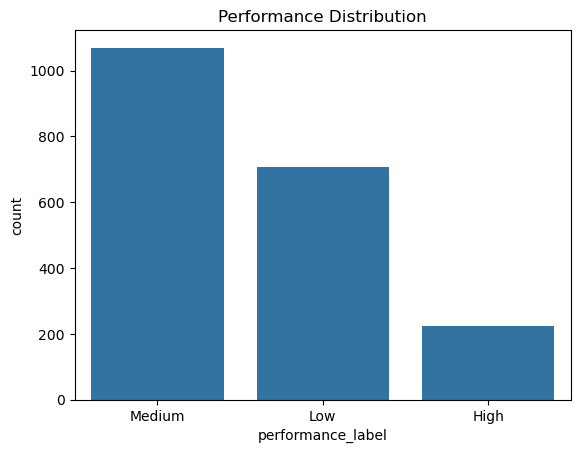

In [9]:
sns.countplot(x='performance_label', data=df)
plt.title('Performance Distribution')
plt.show()


### EDA

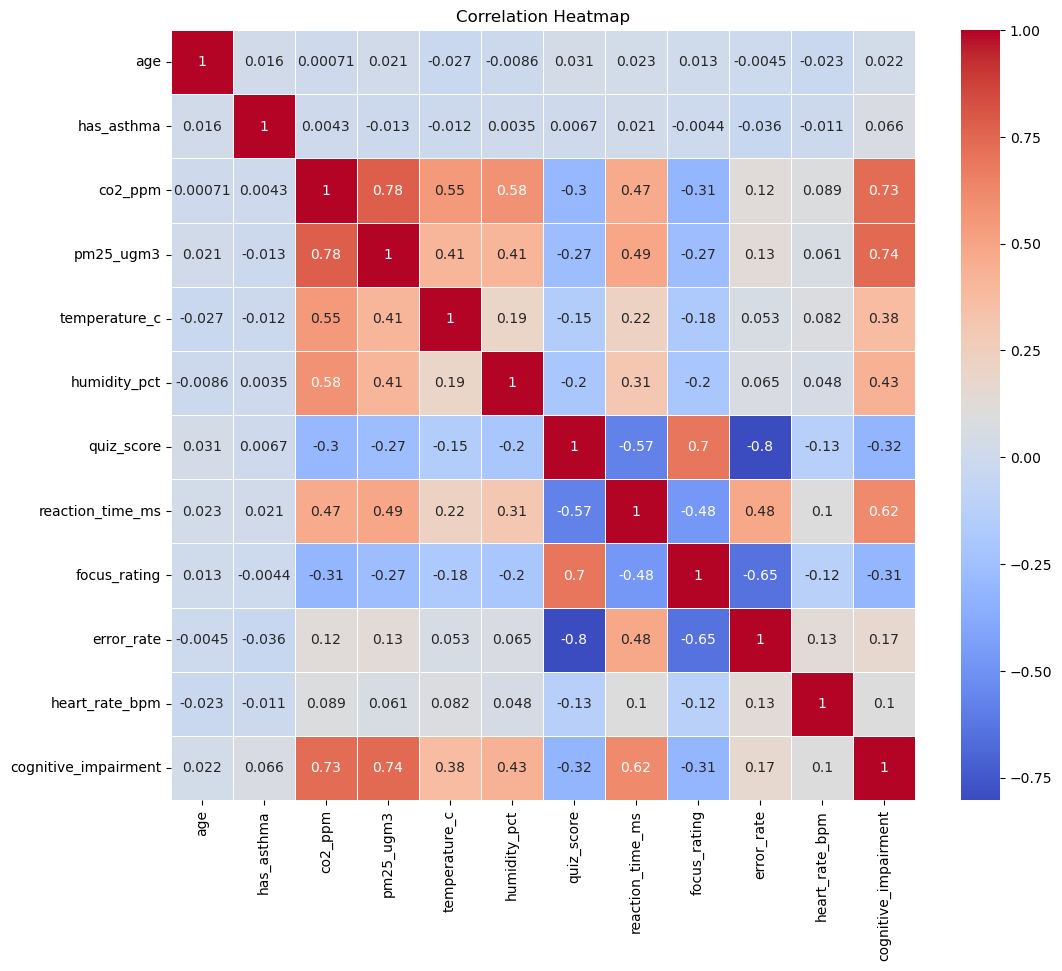

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    annot=True, 
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.show()

In [11]:
numerical_columns = [
    "co2_ppm",
    "pm25_ugm3",
    "temperature_c",
    "humidity_pct",
    "quiz_score"
]

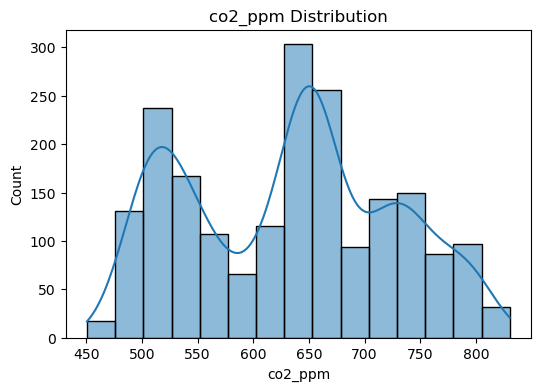

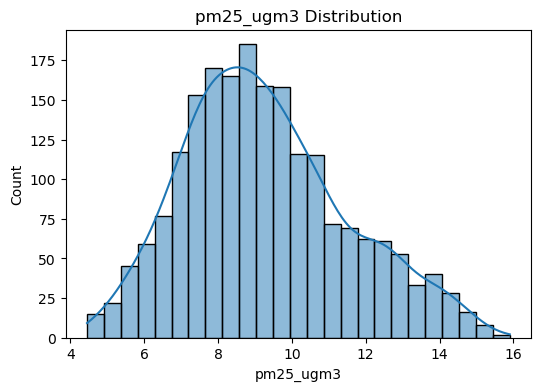

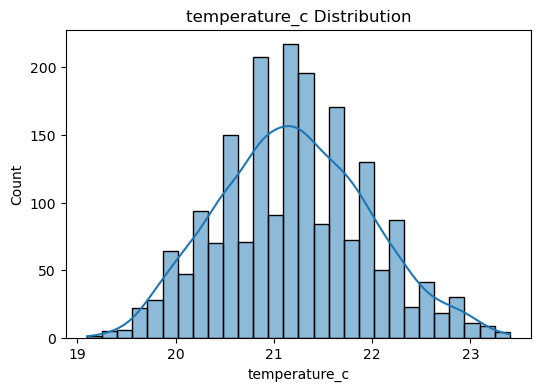

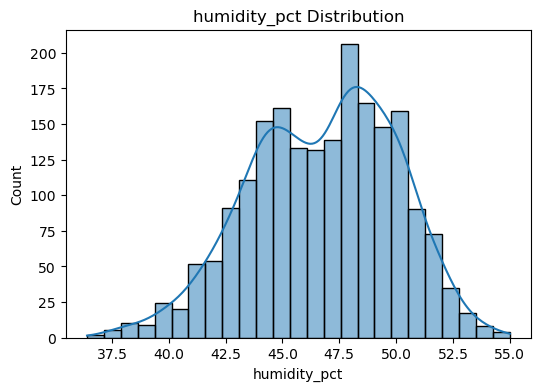

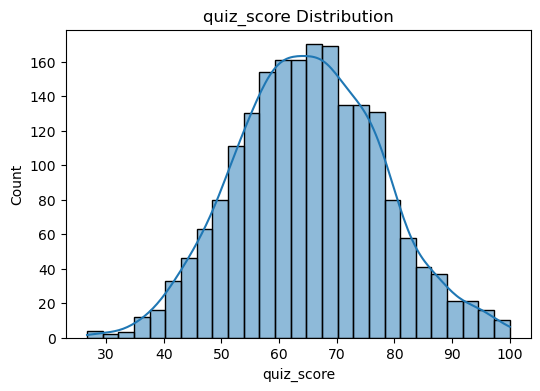

In [12]:
for column in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[column], kde=True)
    plt.title(f"{column} Distribution")
    plt.show()

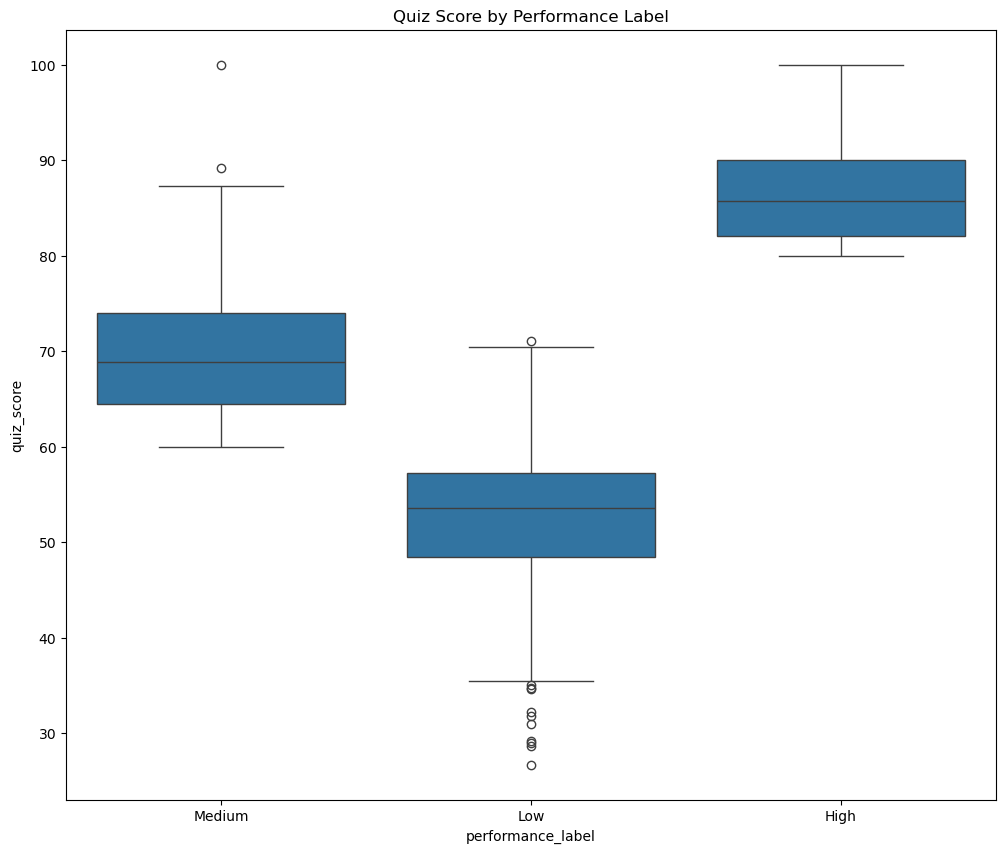

In [13]:
plt.figure(figsize=(12, 10))
sns.boxplot(
    x='performance_label',
    y='quiz_score',
    data=df
)
plt.title('Quiz Score by Performance Label')
plt.show()

### Data Cleaning and Preprocessing


In [14]:
df.head(3)

,student_id,day,period,subject,grade,age,has_asthma,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,air_quality_label,quiz_score,reaction_time_ms,focus_rating,error_rate,heart_rate_bpm,cognitive_impairment,performance_label
0,STU0001,Friday,1st Period,Mathematics,Grade 11,14,1,504.4,8.61,21.3,45.3,Good,74.9,245,8.2,1.59,67,0.0108,Medium
1,STU0005,Friday,1st Period,Mathematics,Grade 8,15,0,542.6,8.58,21.0,42.0,Good,58.8,238,5.9,2.47,75,0.0121,Low
2,STU0006,Friday,1st Period,Mathematics,Grade 9,12,0,541.2,8.05,20.8,44.4,Good,81.0,203,7.8,0.41,75,0.0195,High


In [15]:
df=df.drop(columns=['student_id'])

In [16]:
df.head(2)

,day,period,subject,grade,age,has_asthma,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,air_quality_label,quiz_score,reaction_time_ms,focus_rating,error_rate,heart_rate_bpm,cognitive_impairment,performance_label
0,Friday,1st Period,Mathematics,Grade 11,14,1,504.4,8.61,21.3,45.3,Good,74.9,245,8.2,1.59,67,0.0108,Medium
1,Friday,1st Period,Mathematics,Grade 8,15,0,542.6,8.58,21.0,42.0,Good,58.8,238,5.9,2.47,75,0.0121,Low


#### Encoding

In [17]:
grade_mapping = {
    "Grade 6": 6,
    "Grade 7": 7,
    "Grade 8": 8,
    "Grade 9": 9,
    "Grade 10": 10,
    "Grade 11": 11,
}

In [18]:
df["grade"] = df["grade"].map(grade_mapping)

In [19]:
df.head(3)

,day,period,subject,grade,age,has_asthma,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,air_quality_label,quiz_score,reaction_time_ms,focus_rating,error_rate,heart_rate_bpm,cognitive_impairment,performance_label
0,Friday,1st Period,Mathematics,11,14,1,504.4,8.61,21.3,45.3,Good,74.9,245,8.2,1.59,67,0.0108,Medium
1,Friday,1st Period,Mathematics,8,15,0,542.6,8.58,21.0,42.0,Good,58.8,238,5.9,2.47,75,0.0121,Low
2,Friday,1st Period,Mathematics,9,12,0,541.2,8.05,20.8,44.4,Good,81.0,203,7.8,0.41,75,0.0195,High


In [20]:
df.isnull().sum()

day                     0
period                  0
subject                 0
grade                   0
age                     0
has_asthma              0
co2_ppm                 0
pm25_ugm3               0
temperature_c           0
humidity_pct            0
air_quality_label       0
quiz_score              0
reaction_time_ms        0
focus_rating            0
error_rate              0
heart_rate_bpm          0
cognitive_impairment    0
performance_label       0
dtype: int64

In [21]:
air_quality_mapping = {
    "Poor": 0,
    "Moderate": 1,
    "Good": 2
}

In [22]:
df["air_quality_label"] = df[
    "air_quality_label"
].map(air_quality_mapping)

In [23]:
df.head()

,day,period,subject,grade,age,has_asthma,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,air_quality_label,quiz_score,reaction_time_ms,focus_rating,error_rate,heart_rate_bpm,cognitive_impairment,performance_label
0,Friday,1st Period,Mathematics,11,14,1,504.4,8.61,21.3,45.3,2,74.9,245,8.2,1.59,67,0.0108,Medium
1,Friday,1st Period,Mathematics,8,15,0,542.6,8.58,21.0,42.0,2,58.8,238,5.9,2.47,75,0.0121,Low
2,Friday,1st Period,Mathematics,9,12,0,541.2,8.05,20.8,44.4,2,81.0,203,7.8,0.41,75,0.0195,High
3,Friday,1st Period,Mathematics,9,17,1,525.9,8.56,20.5,44.4,2,74.2,206,6.8,1.11,80,0.0200,Medium
4,Friday,1st Period,Mathematics,11,17,0,529.3,7.23,20.3,44.4,2,58.5,240,6.6,2.16,77,0.0106,Low


In [24]:
X = df.drop("performance_label", axis=1)

In [25]:
y = df["performance_label"]

In [26]:
categorical_columns = [
    "day",
    "period",
    "subject"
]

In [27]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

In [28]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [29]:
X.head()

,grade,age,has_asthma,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,air_quality_label,quiz_score,reaction_time_ms,...,day_Tuesday,day_Wednesday,period_2nd Period,period_3rd Period,period_4th Period,period_5th Period,subject_English,subject_History,subject_Mathematics,subject_Physics
0,11,14,1,504.4,8.61,21.3,45.3,2,74.9,245,...,False,False,False,False,False,False,False,False,True,False
1,8,15,0,542.6,8.58,21.0,42.0,2,58.8,238,...,False,False,False,False,False,False,False,False,True,False
2,9,12,0,541.2,8.05,20.8,44.4,2,81.0,203,...,False,False,False,False,False,False,False,False,True,False
3,9,17,1,525.9,8.56,20.5,44.4,2,74.2,206,...,False,False,False,False,False,False,False,False,True,False
4,11,17,0,529.3,7.23,20.3,44.4,2,58.5,240,...,False,False,False,False,False,False,False,False,True,False


In [30]:
df.isnull().sum()

day                     0
period                  0
subject                 0
grade                   0
age                     0
has_asthma              0
co2_ppm                 0
pm25_ugm3               0
temperature_c           0
humidity_pct            0
air_quality_label       0
quiz_score              0
reaction_time_ms        0
focus_rating            0
error_rate              0
heart_rate_bpm          0
cognitive_impairment    0
performance_label       0
dtype: int64

In [31]:
X.shape

(2000, 26)

### Train test split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature scaling

In [33]:
scaler = StandardScaler()

In [34]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train models



#### Logistic regression

In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
logistic_model = LogisticRegression(max_iter=1000)

In [37]:
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

#### Random forest

In [38]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [39]:
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

#### Knn

In [40]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [41]:
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

### Predictions

In [42]:
log_predictions = logistic_model.predict(X_test_scaled)

In [43]:
knn_predictions = knn_model.predict(X_test_scaled)

In [44]:
rf_predictions = rf_model.predict(X_test_scaled)

### Evaluation

In [45]:
def evaluate_classification_model(name,y_test, predictions):
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')  
    f1 = f1_score(y_test, predictions, average='weighted')
    print(f"{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")    
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")    

    print("\nClassification Report:")
    print(classification_report(y_test, predictions))
    return[name, accuracy, precision, recall, f1]

#### for each model

In [46]:
results=[]
results.append(evaluate_classification_model("Logistic Regression", y_test, log_predictions))
results.append(evaluate_classification_model("KNN Classifier", y_test, knn_predictions))
results.append(evaluate_classification_model("Random Forest Classifier", y_test, rf_predictions))

Logistic Regression Performance:
Accuracy: 0.9550
Precision: 0.9549
Recall: 0.9550
F1 Score: 0.9549

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.96      0.97      0.96       144
           2       0.96      0.96      0.96       214

    accuracy                           0.95       400
   macro avg       0.95      0.94      0.95       400
weighted avg       0.95      0.95      0.95       400

KNN Classifier Performance:
Accuracy: 0.7400
Precision: 0.7515
Recall: 0.7400
F1 Score: 0.7240

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.24      0.37        42
           1       0.78      0.71      0.74       144
           2       0.71      0.86      0.78       214

    accuracy                           0.74       400
   macro avg       0.78      0.60      0.63       400
weighted avg       0.75      0.74      0.72       

### Comparision table

In [47]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

In [48]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.955,0.954921,0.955,0.954942
1,KNN Classifier,0.740,0.751512,0.740,0.724037
2,Random Forest Classifier,0.985,0.985014,0.985,0.984977


### Comaprision graph

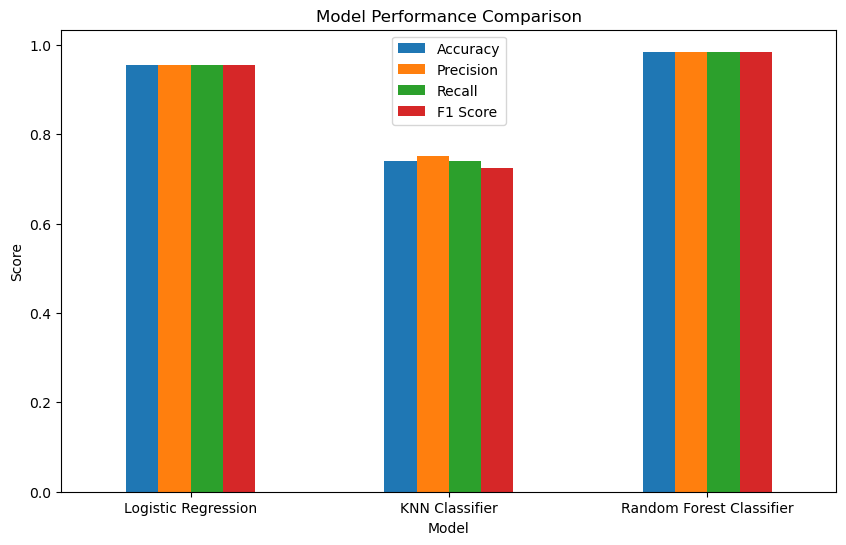

In [49]:
results_df.plot(
    x="Model",
    y=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    kind="bar",
    figsize=(10,6)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

### Confusion Matrix for rf(as it is the best performing)

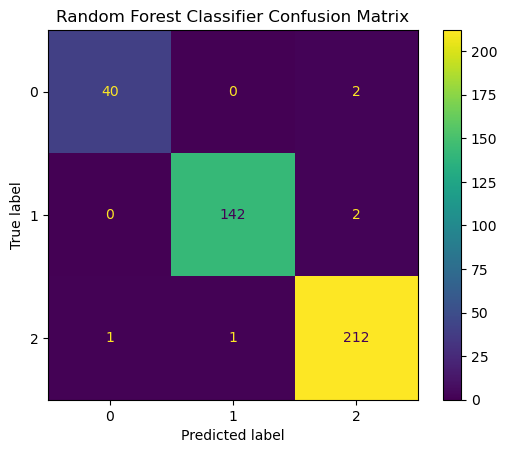

In [50]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test_scaled,
    y_test
    )
plt.title("Random Forest Classifier Confusion Matrix")
plt.show()


### PCA

In [51]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

C:\Users\summi\AppData\Local\Temp\ipykernel_25648\109388868.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


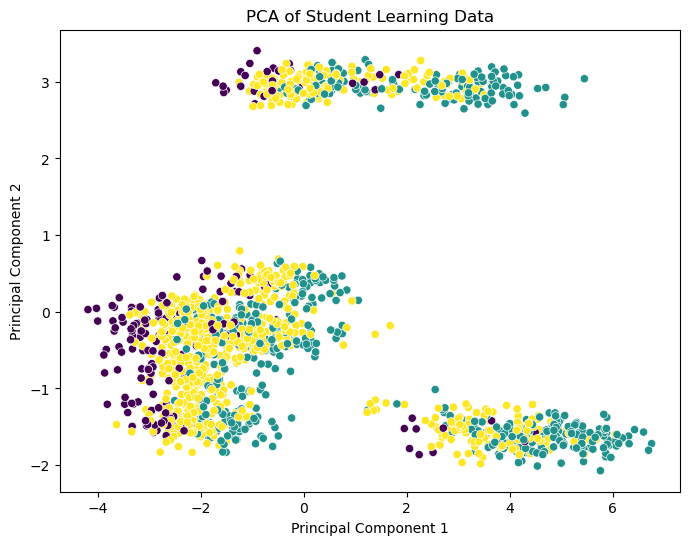

In [52]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    c = y_train,
    palette='Set1'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Student Learning Data")
plt.show()

### Feature importance


In [53]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_})

In [56]:
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

In [57]:
feature_importance.head(10)

,Feature,Importance
8,quiz_score,0.586562
11,error_rate,0.155798
10,focus_rating,0.078581
9,reaction_time_ms,0.039388
13,cognitive_impairment,0.022853
3,co2_ppm,0.020499
4,pm25_ugm3,0.019196
6,humidity_pct,0.013929
5,temperature_c,0.012716
12,heart_rate_bpm,0.012309


C:\Users\summi\AppData\Local\Temp\ipykernel_25648\4026873308.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


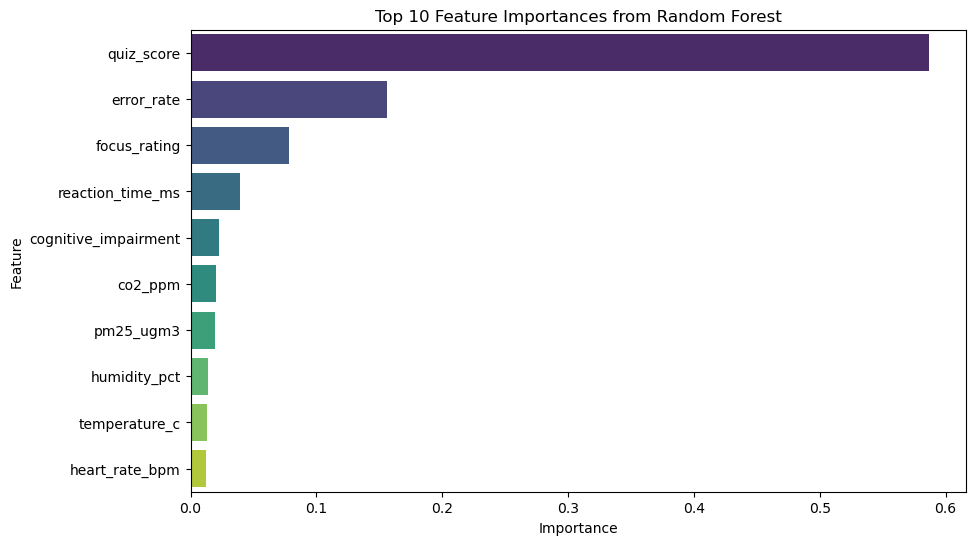

In [58]:
top_features = feature_importance.head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features,
    palette='viridis'
)
plt.title("Top 10 Feature Importances from Random Forest")
plt.xlabel("Importance")
plt.show()

### Training and testing accuracy

In [54]:
print("Training Accuracy:")
print(rf_model.score(X_train_scaled, y_train))

Training Accuracy:
1.0


In [55]:
print("\nTesting Accuracy:")
print(rf_model.score(X_test_scaled, y_test))


Testing Accuracy:
0.985


##### training>testing = overfitted sadly